# Lab 7 — Classification Metrics + Cross-Validation

## Learning goals

By the end of this lab, you can:

- Read a **confusion matrix**
- Compute and interpret **accuracy, precision, recall, F1-score**
- Use **classification_report**
- Visualize confusion matrix
- Understand **k-fold cross-validation**
- Compute **cross-validation scores**

---

# Part A — Core classification metrics (Theory)

## 1) Confusion Matrix (the starting point)
For binary classification:

|                | Predicted 1 | Predicted 0 |
|----------------|-------------|-------------|
| **Actual 1**   | TP          | FN          |
| **Actual 0**   | FP          | TN          |

- **TP**: true positives (correctly predicted 1)
- **TN**: true negatives (correctly predicted 0)
- **FP**: false positives (predicted 1 but actually 0)
- **FN**: false negatives (predicted 0 but actually 1)

Confusion matrix helps you see *what types of mistakes* the model makes.

---

## 2) Precision vs Recall
### Precision
$$\text{Precision} = \frac{TP}{TP + FP}$$  
Out of all predicted positives, **how many were correct?**  
Important when **false positives are costly** (e.g., spam filter).

### Recall
$$\text{Recall} = \frac{TP}{TP + FN}$$  
Out of all actual positives, **how many did we catch?**  
Important when **false negatives are costly** (e.g., disease detection).

---

## 3) F1-score
F1 is the harmonic mean of precision and recall:

$$F1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

- High F1 means both precision and recall are reasonably high.
- Useful when classes are imbalanced.

---

## 4) Classification Report
A built-in summary table containing:
- precision
- recall
- f1-score
- support (number of samples in each class)

It helps compare class-by-class performance in multi-class classification too.

---

# Part B — Cross-validation (Theory)

## 5) Why cross-validation?
A single train-test split may be “lucky” or “unlucky”.
Cross-validation gives a more reliable estimate of model performance.

---

## 6) K-Fold Cross Validation
- Split data into **K folds** (e.g., K=5)
- Train on K-1 folds, test on the remaining fold
- Repeat K times, each fold is used as test once
- Average the scores

This produces **cross-validation score(s)**.

---

## 7) Cross-validation score
This is the average performance across folds, e.g. average accuracy or average F1.


In [ ]:
# This code block performs the task as described in the markdown cell above.
# ------------------------------------------------------------# Lab 7 Code: Metrics + Confusion Matrix + Cross Validation# Dataset: Iris (multi-class classification)# Model: Logistic Regression# ------------------------------------------------------------import numpy as npimport matplotlib.pyplot as pltfrom sklearn.datasets import load_irisfrom sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_scorefrom sklearn.pipeline import Pipelinefrom sklearn.preprocessing import StandardScalerfrom sklearn.linear_model import LogisticRegressionfrom sklearn.metrics import (    accuracy_score,    precision_score,    recall_score,    f1_score,    confusion_matrix,    classification_report,    ConfusionMatrixDisplay)

In [ ]:
# This code block performs the task as described in the markdown cell above.
# 1) Load datasetiris = load_iris()X, y = iris.data, iris.targetclass_names = iris.target_namesprint("X shape:", X.shape)print("y shape:", y.shape)print("Classes:", class_names)

X shape: (150, 4)
y shape: (150,)
Classes: ['setosa' 'versicolor' 'virginica']


In [ ]:
# This code block performs the task as described in the markdown cell above.
# 2) Train-test split (single split evaluation)X_train, X_test, y_train, y_test = train_test_split(    X, y, test_size=0.2, random_state=42, stratify=y)# 3) Pipeline: scaling + classifier (good practice, avoids leakage)model = Pipeline([    ("scaler", StandardScaler()),    ("clf", LogisticRegression(max_iter=200, random_state=42))])model.fit(X_train, y_train)y_pred = model.predict(X_test)model.score(X_test, y_test)

0.9333333333333333

In [ ]:
# This code block performs the task as described in the markdown cell above.
# 4) Basic metrics (Accuracy + Precision/Recall/F1)# NOTE: For multi-class, we must specify averaging method:# - 'macro' = average across classes equally# - 'weighted' = average weighted by class supportacc = accuracy_score(y_test, y_pred)prec = precision_score(y_test, y_pred, average="macro")rec = recall_score(y_test, y_pred, average="macro")f1 = f1_score(y_test, y_pred, average="macro")print("Accuracy :", acc)print("Precision:", prec)print("Recall   :", rec)print("F1-score :", f1)

Accuracy : 0.9333333333333333
Precision: 0.9333333333333332
Recall   : 0.9333333333333332
F1-score : 0.9333333333333332


In [ ]:
# This code block performs the task as described in the markdown cell above.
# 5) Classification report (precision/recall/f1 per class)print(classification_report(y_test, y_pred, target_names=class_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



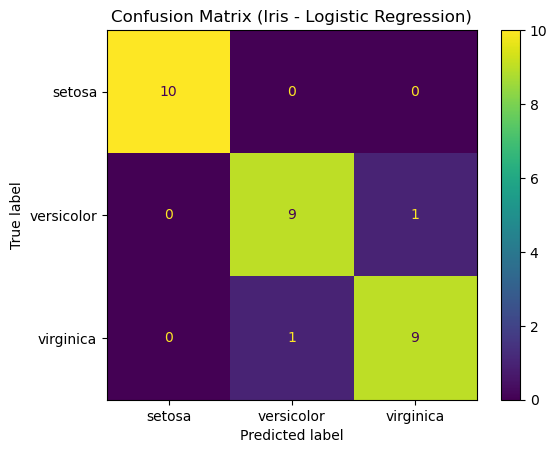

In [ ]:
# This code block performs the task as described in the markdown cell above.
# 6) Confusion matrix + visualizationcm = confusion_matrix(y_test, y_pred)disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)disp.plot(values_format="d")plt.title("Confusion Matrix (Iris - Logistic Regression)")plt.show()

In [ ]:
# This code block performs the task as described in the markdown cell above.
from sklearn.model_selection import KFoldkf = KFold(n_splits=4)for train_index, test_index in kf.split([1,2,3,4,5,6,7,8,9,11,12,13,14,15]):  print(train_index, test_index)

[ 4  5  6  7  8  9 10 11 12 13] [0 1 2 3]
[ 0  1  2  3  8  9 10 11 12 13] [4 5 6 7]
[ 0  1  2  3  4  5  6  7 11 12 13] [ 8  9 10]
[ 0  1  2  3  4  5  6  7  8  9 10] [11 12 13]


In [ ]:
# This code block performs the task as described in the markdown cell above.
# 7) K-Fold Cross Validation (StratifiedKFold keeps class ratio similar in each fold)kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)# Cross-validation scores using accuracycv_scores_acc = cross_val_score(model, X, y, cv=kfold, scoring="accuracy")print("CV Accuracy scores:", cv_scores_acc)print("Mean CV Accuracy  :", cv_scores_acc.mean())print("Std CV Accuracy   :", cv_scores_acc.std())

CV Accuracy scores: [1.         0.96666667 0.9        1.         0.9       ]
Mean CV Accuracy  : 0.9533333333333334
Std CV Accuracy   : 0.04521553322083511


In [ ]:
# This code block performs the task as described in the markdown cell above.
# 8) Cross-validation scores using F1 (for multi-class use f1_macro)cv_scores_f1 = cross_val_score(model, X, y, cv=kfold, scoring="f1_macro")cprint("CV F1_macro scores:", cv_scores_f1)print("Mean CV F1_macro  :", cv_scores_f1.mean())print("Std CV F1_macro   :", cv_scores_f1.std())

CV F1_macro scores: [1.         0.96658312 0.89974937 1.         0.89974937]
Mean CV F1_macro  : 0.953216374269006
Std CV F1_macro   : 0.0453288553592332


- Confusion matrix tells you *what kind of errors* happen.
- Precision/Recall tradeoff depends on the problem.
- F1 is a balance of precision and recall.
- Cross-validation gives more reliable performance than one split.

# Grid Search CV

Most ML models have **hyperparameters** (settings we choose before training), such as:
- KNN: number of neighbors `k`
- SVM: `C`, `gamma`, kernel
- Decision Tree: `max_depth`, `min_samples_split`
- Random Forest: `n_estimators`, `max_depth`

These hyperparameters strongly affect performance.  
If we pick them randomly, the model may **underfit** or **overfit**.

---

## Why Grid Search CV is needed
If we tune hyperparameters using the **test set**, we create **data leakage** and the test accuracy becomes unrealistic.

So the correct idea is:

1) Keep the test set untouched (for final evaluation only)
2) Use only training data for tuning
3) Use cross-validation to get a reliable score

Grid Search CV does exactly this.

---

## What Grid Search CV does
**GridSearchCV** tries many hyperparameter combinations and uses **cross-validation** to score each one.

Example: for SVM, it may try:
- `C ∈ {0.1, 1, 10}`
- `gamma ∈ {0.01, 0.1, 1}`

That makes 9 combinations.  
For each combination, it runs K-fold CV and computes an average score.

It then selects the combination with the best average CV score.

---

## Summary
- **Grid** = list of hyperparameter values to try  
- **Search** = try every combination  
- **CV** = evaluate each combination fairly using K-fold cross-validation  

**Result**: you get the **best hyperparameters** without touching the test set.

In [ ]:
# This code block performs the task as described in the markdown cell above.
from sklearn import svm, datasetsiris = datasets.load_iris()import pandas as pddf=pd.DataFrame(iris.data, columns=iris.feature_names)df['flower']=iris.target# df['flower'] = df['flower'].apply(lambda x: iris.target_names[x])df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),flower
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [ ]:
# This code block performs the task as described in the markdown cell above.
from sklearn.model_selection import train_test_splitX_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.3)model = svm.SVC(kernel='rbf', C=30, gamma='auto')model.fit(X_train, y_train)model.score(X_test, y_test)

0.9777777777777777

In [ ]:
# This code block performs the task as described in the markdown cell above.
from sklearn.model_selection import cross_val_scorecross_val_score(svm.SVC(kernel='rbf', C=10, gamma='auto'), iris.data, iris.target, cv=5)

array([0.96666667, 1.        , 0.96666667, 0.96666667, 1.        ])

In [ ]:
# This code block performs the task as described in the markdown cell above.
cross_val_score(svm.SVC(kernel='rbf', C=2, gamma='auto'), iris.data, iris.target, cv=5)

array([0.96666667, 1.        , 0.96666667, 0.96666667, 1.        ])

In [ ]:
# This code block performs the task as described in the markdown cell above.
import numpy as npkernels = ['rbf', 'linear']C = [1,10,20]avg_sc={}for kval in kernels:  for cval in C:    cv_score = cross_val_score(svm.SVC(kernel=kval, C=cval, gamma='auto'), iris.data, iris.target, cv=5)    avg_sc[kval+'_'+str(cval)] = np.mean(cv_score)

In [ ]:
# This code block performs the task as described in the markdown cell above.
avg_sc

{'rbf_1': np.float64(0.9800000000000001),
 'rbf_10': np.float64(0.9800000000000001),
 'rbf_20': np.float64(0.9666666666666668),
 'linear_1': np.float64(0.9800000000000001),
 'linear_10': np.float64(0.9733333333333334),
 'linear_20': np.float64(0.9666666666666666)}

In [ ]:
# This code block performs the task as described in the markdown cell above.
from sklearn.model_selection import GridSearchCVfrom sklearn.model_selection import RandomizedSearchCV

In [ ]:
# This code block performs the task as described in the markdown cell above.
rfs = RandomizedSearchCV(svm.SVC(gamma='auto'),                         {                             'C':[1,10,20],                             'kernel':['rbf','linear']                         },                         cv=5,                         return_train_score=False,                         n_iter=2                         )rfs.fit(iris.data, iris.target)

,estimator,SVC(gamma='auto')
,param_distributions,"{'C': [1, 10, ...], 'kernel': ['rbf', 'linear']}"
,n_iter,2
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [ ]:
# This code block performs the task as described in the markdown cell above.
clf = GridSearchCV(svm.SVC(gamma='auto'),                   {                       'C':[1,10,20],                       'kernel':['rbf', 'linear']                   }, cv=5, return_train_score=False)clf.fit(iris.data, iris.target)

,estimator,SVC(gamma='auto')
,param_grid,"{'C': [1, 10, ...], 'kernel': ['rbf', 'linear']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,1


In [ ]:
# This code block performs the task as described in the markdown cell above.
clf.cv_results_

{'mean_fit_time': array([0.00100045, 0.00070539, 0.00057001, 0.00030575, 0.0003058 ,
        0.00025382]),
 'std_fit_time': array([4.24117111e-04, 1.50694017e-04, 8.27967552e-05, 3.86710526e-05,
        1.08888143e-05, 6.50249250e-06]),
 'mean_score_time': array([0.00052786, 0.00047736, 0.00032043, 0.00019054, 0.00018134,
        0.00015159]),
 'std_score_time': array([1.31839826e-04, 1.48187717e-04, 6.22919813e-05, 1.61473988e-05,
        5.21608416e-06, 1.39347450e-06]),
 'param_C': masked_array(data=[1, 1, 10, 10, 20, 20],
              mask=[False, False, False, False, False, False],
        fill_value=999999),
 'param_kernel': masked_array(data=['rbf', 'linear', 'rbf', 'linear', 'rbf', 'linear'],
              mask=[False, False, False, False, False, False],
        fill_value=np.str_('?'),
             dtype=object),
 'params': [{'C': 1, 'kernel': 'rbf'},
  {'C': 1, 'kernel': 'linear'},
  {'C': 10, 'kernel': 'rbf'},
  {'C': 10, 'kernel': 'linear'},
  {'C': 20, 'kernel': 'rbf'},
 

In [ ]:
# This code block performs the task as described in the markdown cell above.
df = pd.DataFrame(clf.cv_results_)df

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_kernel,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.001000,0.000424,0.000528,0.000132,1,rbf,"{'C': 1, 'kernel': 'rbf'}",0.966667,1.0,0.966667,0.966667,1.0,0.980000,0.016330,1
1,0.000705,0.000151,0.000477,0.000148,1,linear,"{'C': 1, 'kernel': 'linear'}",0.966667,1.0,0.966667,0.966667,1.0,0.980000,0.016330,1
2,0.000570,0.000083,0.000320,0.000062,10,rbf,"{'C': 10, 'kernel': 'rbf'}",0.966667,1.0,0.966667,0.966667,1.0,0.980000,0.016330,1
3,0.000306,0.000039,0.000191,0.000016,10,linear,"{'C': 10, 'kernel': 'linear'}",1.000000,1.0,0.900000,0.966667,1.0,0.973333,0.038873,4
4,0.000306,0.000011,0.000181,0.000005,20,rbf,"{'C': 20, 'kernel': 'rbf'}",0.966667,1.0,0.900000,0.966667,1.0,0.966667,0.036515,5
5,0.000254,0.000007,0.000152,0.000001,20,linear,"{'C': 20, 'kernel': 'linear'}",1.000000,1.0,0.900000,0.933333,1.0,0.966667,0.042164,6


In [ ]:
# This code block performs the task as described in the markdown cell above.
df[['params','mean_test_score']]

,params,mean_test_score
0,"{'C': 1, 'kernel': 'rbf'}",0.980000
1,"{'C': 1, 'kernel': 'linear'}",0.980000
2,"{'C': 10, 'kernel': 'rbf'}",0.980000
3,"{'C': 10, 'kernel': 'linear'}",0.973333
4,"{'C': 20, 'kernel': 'rbf'}",0.966667
5,"{'C': 20, 'kernel': 'linear'}",0.966667


In [ ]:
# This code block performs the task as described in the markdown cell above.
clf.best_params_

{'C': 1, 'kernel': 'rbf'}

In [ ]:
# This code block performs the task as described in the markdown cell above.
clf.best_score_

np.float64(0.9800000000000001)

In [ ]:
# This code block performs the task as described in the markdown cell above.
from sklearn.svm import SVCfrom sklearn.ensemble import RandomForestClassifierfrom sklearn.linear_model import LogisticRegressionmodel_params = {    'SVM': {        'model':svm.SVC(),        'params':        {            'C':[1,10,20],            'gamma':['scale', 'auto'],            'kernel':['rbf', 'linear']        }    },    'RandomForest':{        'model':RandomForestClassifier(),        'params':{            'n_estimators':[1,5,10]        }    },    'LogisticRegression':{        'model':LogisticRegression(),        'params':{            'solver':['lbfgs', 'liblinear'],            'multi_class':['auto','ovr', 'multinomial'],            'C':[1,5,10]        }    }}

In [ ]:
# This code block performs the task as described in the markdown cell above.
scores = []for model_name, mp in model_params.items():    clf =  GridSearchCV(mp['model'], mp['params'], cv=5, return_train_score=False)    clf.fit(iris.data, iris.target)    scores.append({        'model': model_name,        'best_score': clf.best_score_,        'best_params': clf.best_params_    })df = pd.DataFrame(scores,columns=['model','best_score','best_params'])df

In [ ]:
# This code block performs the task as described in the markdown cell above.
df

,model,best_score,best_params
0,SVM,0.980000,"{'C': 1, 'gamma': 'scale', 'kernel': 'linear'}"
1,RandomForest,0.966667,{'n_estimators': 10}
2,LogisticRegression,0.980000,"{'C': 10, 'multi_class': 'auto', 'solver': 'lb..."
